Mean Squared Error: 0.3819
R-squared Score: -0.1727


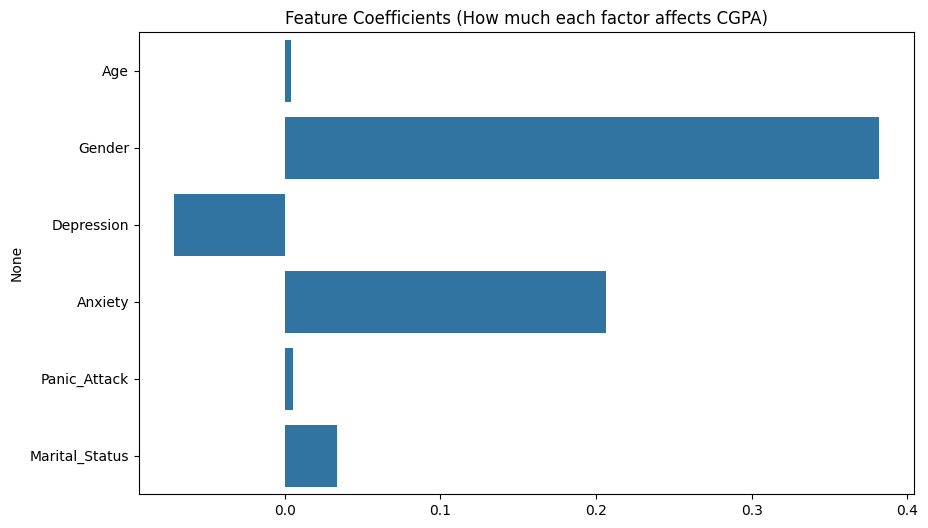

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Student Mental health.csv')
df.columns = ['Timestamp', 'Gender', 'Age', 'Course', 'Year', 'CGPA', 'Marital_Status',
              'Depression', 'Anxiety', 'Panic_Attack', 'Treatment']
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Gender'] = df['Gender'].map({'Female': 1, 'Male': 0})
df['Depression'] = df['Depression'].map({'Yes': 1, 'No': 0})
df['Anxiety'] = df['Anxiety'].map({'Yes': 1, 'No': 0})
df['Panic_Attack'] = df['Panic_Attack'].map({'Yes': 1, 'No': 0})
df['Marital_Status'] = df['Marital_Status'].map({'Yes': 1, 'No': 0})
def cgpa_to_numeric(cgpa_str):
    try:
        parts = str(cgpa_str).strip().split('-')
        if len(parts) == 2:
            return (float(parts[0]) + float(parts[1])) / 2
        return float(cgpa_str)
    except:
        return np.nan
df['CGPA_Score'] = df['CGPA'].apply(cgpa_to_numeric)
df = df.dropna(subset=['CGPA_Score'])
X = df[['Age', 'Gender', 'Depression', 'Anxiety', 'Panic_Attack', 'Marital_Status']]
y = df['CGPA_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")
plt.figure(figsize=(10, 6))
sns.barplot(x=model.coef_, y=X.columns)
plt.title('Feature Coefficients (How much each factor affects CGPA)')
plt.show()